## Obtaining the Efficient Frontier - Part III

*Suggested Answers follow (usually there are multiple ways to solve a problem in Python).*

Ok, let’s continue the exercise from the last lecture.

In [8]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
%matplotlib inline

assets = ['WMT', 'FB']
pf_data = pd.read_csv(r'C:\Users\Admin\OneDrive\Documents\bt ptdl\bt_tuan_ptdl\DA07 - Phan tich du lieu tai chinh\04_normative_finance\04_normative_finance\01_Obtaining the Efficient Frontier_1\csv\Walmart_FB_2014_2017.csv', index_col='Date')

In [9]:
log_returns = np.log(pf_data / pf_data.shift(1))

num_assets = len(assets)

weights = np.random.random(num_assets)
weights /= np.sum(weights)
weights

array([0.72476337, 0.27523663])

Now, estimate the expected Portfolio Return, Variance, and Volatility.

Expected Portfolio Return:

In [10]:
np.sum(weights * log_returns.mean()) * 250

np.float64(0.08168736068093826)

Expected Portfolio Variance:

In [11]:
np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))

np.float64(0.026342553915643732)

Expected Portfolio Volatility:

In [12]:
np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights)))

np.float64(0.16230389371682902)

***

The rest of this exercise will be a reproduction of what we did in the previous video.

1)	Create two empty lists. Name them pf_returns and pf_volatilites.

In [13]:
pf_returns = []
pf_volatilities = []

2)	Create a loop with 1,000 iterations that will generate random weights, summing to 1, and will append the obtained values for the portfolio returns and the portfolio volatilities to pf_returns and pf_volatilities, respectively.

In [14]:
for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pf_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pf_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))
    
pf_returns, pf_volatilities

([np.float64(0.19262566325332542),
  np.float64(0.2702582629055094),
  np.float64(0.17581459014043668),
  np.float64(0.19397065910526196),
  np.float64(0.04420973465476733),
  np.float64(0.1277597701567684),
  np.float64(0.18911888093608076),
  np.float64(0.20110221868826303),
  np.float64(0.1083105942016142),
  np.float64(0.04467356798436464),
  np.float64(0.09656882123566624),
  np.float64(0.11282633012657105),
  np.float64(0.14062375885764986),
  np.float64(0.27226675616786145),
  np.float64(0.19674959230550498),
  np.float64(0.18576343986982968),
  np.float64(0.19570322069356016),
  np.float64(0.02916383285415657),
  np.float64(0.14298550857590492),
  np.float64(0.10478216553058425),
  np.float64(0.09211910608765882),
  np.float64(0.03455802554526943),
  np.float64(0.12759568446832747),
  np.float64(0.12937100964006934),
  np.float64(0.169709785558828),
  np.float64(0.10729914900372987),
  np.float64(0.1045176873199675),
  np.float64(0.09128494907054736),
  np.float64(0.02505744109

3)	Transform the obtained lists into NumPy arrays and reassign them to pf_returns and pf_volatilites. Once you have done that, the two objects will be NumPy arrays. 

In [15]:
pf_returns = np.array(pf_returns)
pf_volatilities = np.array(pf_volatilities)

pf_returns, pf_volatilities

(array([0.19262566, 0.27025826, 0.17581459, 0.19397066, 0.04420973,
        0.12775977, 0.18911888, 0.20110222, 0.10831059, 0.04467357,
        0.09656882, 0.11282633, 0.14062376, 0.27226676, 0.19674959,
        0.18576344, 0.19570322, 0.02916383, 0.14298551, 0.10478217,
        0.09211911, 0.03455803, 0.12759568, 0.12937101, 0.16970979,
        0.10729915, 0.10451769, 0.09128495, 0.02505744, 0.17307744,
        0.01283039, 0.15797369, 0.1123023 , 0.18575887, 0.05854374,
        0.09623624, 0.25931258, 0.18003906, 0.08174684, 0.14775428,
        0.15035654, 0.16991356, 0.22199599, 0.16524887, 0.01828483,
        0.12722342, 0.26469818, 0.14886877, 0.12932436, 0.12211898,
        0.11301292, 0.19176596, 0.15475142, 0.13460801, 0.13897121,
        0.1164238 , 0.18771529, 0.16849159, 0.07300839, 0.09752675,
        0.2021582 , 0.00519272, 0.14608155, 0.14056648, 0.05533468,
        0.05182475, 0.11186336, 0.13180542, 0.1355606 , 0.12369017,
        0.14932074, 0.12210136, 0.18720151, 0.00

Now, create a dictionary, called portfolios, whose keys are the strings “Return” and “Volatility” and whose values are the NumPy arrays pf_returns and pf_volatilities. 

In [16]:
portfolios = pd.DataFrame({'Return': pf_returns, 'Volatility': pf_volatilities})

In [17]:
portfolios.head()

,Return,Volatility
0,0.192626,0.210108
1,0.270258,0.272365
2,0.175815,0.198865
3,0.193971,0.211051
4,0.044210,0.164340


In [18]:
portfolios.tail()

,Return,Volatility
995,0.161993,0.190462
996,0.227382,0.236228
997,0.009491,0.175025
998,0.185714,0.205360
999,0.140802,0.179305


Finally, plot the data from the portfolios dictionary on a graph. Let the x-axis represent the volatility data from the portfolios dictionary and the y-axis – the data about rates of return. <br />
Organize your chart well and make sure you have labeled both the x- and the y- axes.

Text(0, 0.5, 'Expected Return')

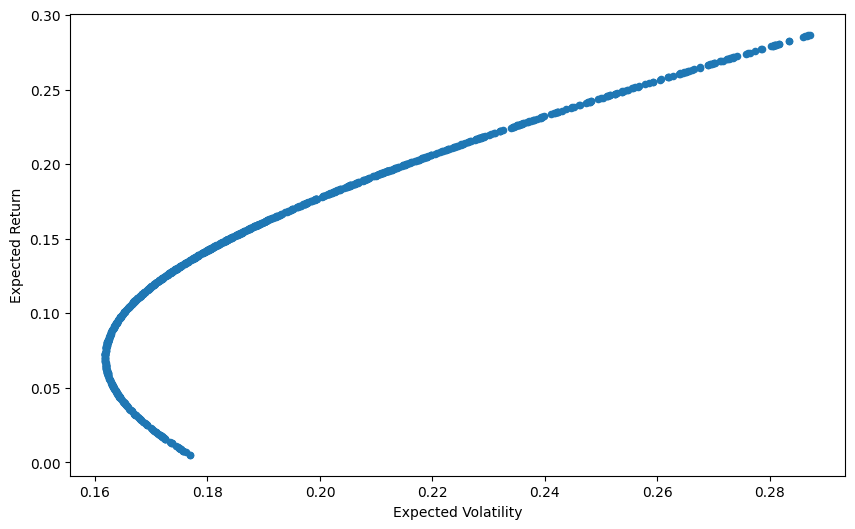

In [19]:
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10, 6));
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')

******

What do you think would happen if you re-created the Markowitz Efficient Frontier for 3 stocks? The code you have created is supposed to accommodate easily the addition of a third stock, say British Petroleum (‘BP’). Insert it in your data and re-run the code (you can expand the “Cell” list from the Jupyter menu and click on “Run All” to execute all the cells at once!). <br />

How would you interpret the obtained graph? 


In [21]:
import yfinance as yf
assets = ['WMT', 'FB', 'BP']
pf_data = pd.DataFrame()

for a in assets:
    pf_data[a] = yf.download(a, start = '2014-1-1')['Close']

C:\Users\Admin\AppData\Local\Temp\ipykernel_19052\3355147184.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_19052\3355147184.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_19052\3355147184.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed


In [22]:
pf_data.head()

,WMT,FB,BP
Date,,,
2014-01-02,20.850979,NaN,24.222164
2014-01-03,20.782284,NaN,24.166615
2014-01-06,20.666018,NaN,24.232250
2014-01-07,20.729437,NaN,24.509916
2014-01-08,20.565609,NaN,24.600784


In [23]:
log_returns = np.log(pf_data / pf_data.shift(1))

In [24]:
num_assets = len(assets)
num_assets

3

In [25]:
weights = np.random.random(num_assets)
weights /= np.sum(weights)
weights

array([0.22197112, 0.5310619 , 0.24696698])

In [26]:
weights[0] + weights[1] + weights[2]

np.float64(1.0)

Expected Portfolio Return:

In [27]:
np.sum(weights * log_returns.mean()) * 250

np.float64(0.1193259173448879)

Expected Portfolio Variance:

In [28]:
np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))

np.float64(0.010097446684893784)

Expected Portfolio Volatility:

In [29]:
np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights)))

np.float64(0.10048605219080797)

*****

In [30]:
pfolio_returns = []
pfolio_volatilities = []

for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pfolio_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))
    
pfolio_returns = np.array(pfolio_returns)
pfolio_volatilities = np.array(pfolio_volatilities)

pfolio_returns, pfolio_volatilities

(array([0.09941575, 0.11223782, 0.06635759, 0.09481839, 0.12043741,
        0.11713322, 0.12383823, 0.11089513, 0.08361842, 0.10279056,
        0.07818728, 0.11781157, 0.10756528, 0.1059102 , 0.10926696,
        0.09365884, 0.10258123, 0.14061241, 0.10186408, 0.12918159,
        0.09920779, 0.1118541 , 0.11765613, 0.11414793, 0.09441357,
        0.09531379, 0.07776385, 0.14581407, 0.1029203 , 0.08212455,
        0.07315736, 0.11371727, 0.08343263, 0.11714603, 0.08621717,
        0.09034373, 0.09541614, 0.08489825, 0.10684316, 0.0772639 ,
        0.08216956, 0.14029787, 0.08212231, 0.1338157 , 0.13251831,
        0.12874296, 0.10701655, 0.09679587, 0.09873167, 0.10200545,
        0.10618486, 0.13007269, 0.10885776, 0.10895923, 0.11860292,
        0.10349438, 0.13079719, 0.13959334, 0.10165929, 0.11579355,
        0.09111873, 0.09831262, 0.10665079, 0.11139944, 0.13970157,
        0.05484805, 0.09141411, 0.12248477, 0.11379543, 0.12843133,
        0.09763174, 0.11460636, 0.10945786, 0.12

In [31]:
portfolios = pd.DataFrame({'Return': pfolio_returns, 'Volatility': pfolio_volatilities})

Text(0, 0.5, 'Expected Return')

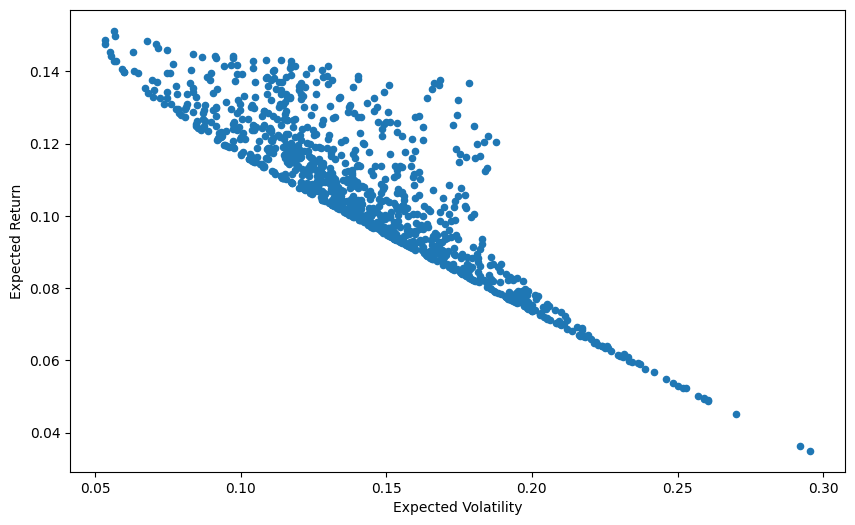

In [32]:
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10, 6));
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')